## Text Splitting 
Process of breaking down large chunks of text into smaller and manageable pieces   
This is needed because -
- LLMs have limited context window, 
- smaller input give faster responses, 
- Focused chunks improve accuracy and quality of response, 
- prevents hallucination
- Optimizes computational resources

### 1. Length based Text Splitting
Simplest and fastest Text Splitting method.    
Splitting can be based on number of tokens, number of characters, number of words 

Downsides -   
Do not care about linguistics, structure, semantic of text 

[Visualize Text Splitting](https://chunkviz.up.railway.app/)

In [7]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import CharacterTextSplitter

In [ ]:
loader = PyPDFLoader("Docs/meri file.pdf")
content = loader.load()

splitter = CharacterTextSplitter(
    separator="",
    chunk_size=100, #100 words
    chunk_overlap=0 #Number of overalaping characters between two chunks
)

splits = splitter.split_documents(content)  #Return list of documents

In [19]:
print(len(content)) # 8 Documents in 'content'
print(len(splits))  # 72 Documents in 'splits' --> Each documents contains max of 100 character 
print(splits[0].page_content)
print(splits[0].metadata)

8
72
#include  <stdio.h>   int  main()  {      int  arr[50]  =  {1,  2,  3,  4};      int  n  =  4;
{'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'meri file file.docx', 'source': 'Docs/meri file.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}


Note - It is generally said that for RAG based applications: 10-20% chunk overalp is good choice to maintain context

### 2. Recursive Text Splitter 
Uses some rules to recursively split the texts.    
It splits text based on this priority - "\n\n" (paragraph), "\n" (line), " " (word), "" (character)
1. The alogrithm looks at number of characters, if the characters are more than required in chunk, it will split paragraphs, then check again, if characters are still more than required in chunk, it will split lines, and so on till it splits through characters if needed. 
2. Then, once all chunks are down to required number of characters or less than that. It will try to merge chunks and if new chunks satisfy required number of characters it will keep them merged in output, otherwise it will not merge chunks. 

(See examples in visualization)

In [20]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [31]:
text = """Uses some rules to recursively split the texts.    

1. The alogrithm looks at number of characters, if the characters are more than required in chunk, it will split paragraphs, then check again, if characters are still more than required in chunk, it will split lines, and so on till it splits through characters if needed. 

2. Then, once all chunks are down to required number of characters or less than that. It will try to merge chunks and if new chunks satisfy required number of characters it will keep them merged in output, otherwise it will not merge chunks. """

splitter = RecursiveCharacterTextSplitter(  #We can also give our own heirarchy as "separater = []"
    separators=[],
    chunk_size = 150,
    chunk_overlap = 30
)

splits = splitter.split_text(text)

In [32]:
print(len(splits))
for split in splits:
    print(split, end="---\n")

5
Uses some rules to recursively split the texts.---
1. The alogrithm looks at number of characters, if the characters are more than required in chunk, it will split paragraphs, then check again, if---
then check again, if characters are still more than required in chunk, it will split lines, and so on till it splits through characters if needed.---
2. Then, once all chunks are down to required number of characters or less than that. It will try to merge chunks and if new chunks satisfy required---
new chunks satisfy required number of characters it will keep them merged in output, otherwise it will not merge chunks.---


### Document Based Text Splitter
This is just Recursive Text Splitter with additional set of "separators".   
For example, for python we may want to split text as this priority list - ['\nClass', '\ndef', '\n\tdef']

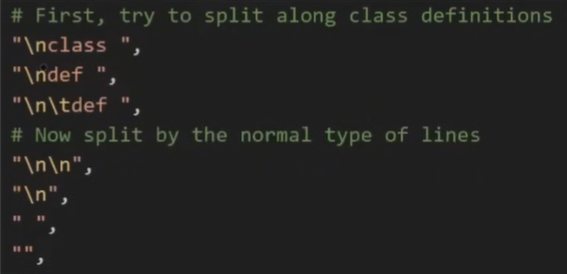

And there are many languages like - JAVA, HTML, Markdown for which this can be uesd

In [44]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language

splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.PYTHON, 
    chunk_size=200,
    chunk_overlap = 0
)


text = """
class RecursiveCharacterTextSplitter(TextSplitter):
    "Splitting text by recursively look at characters.Recursively tries to split by different characters to find one
    that works.
    "
    def __init__(
        self,
        separators: list[str] | None = None,
        keep_separator: bool | Literal["start", "end"] = True,  # noqa: FBT001,FBT002
        is_separator_regex: bool = False,  # noqa: FBT001,FBT002
    ):
        "Create a new TextSplitter."
        super().__init__(keep_separator=keep_separator, **kwargs)
        self._is_separator_regex = is_separator_regex

    def _split_text(self, text: str, separators: list[str]) -> list[str]:
        "Split incoming text and return chunks."
        final_chunks = []
        # Get appropriate separator to use
        separator = separators[-1]
"""

splits = splitter.split_text(text)

In [49]:
print("number of splits: ",len(splits))
for idx, split in enumerate(splits):
    print(idx ,":")
    print(split, end="\n")

number of splits:  6
0 :
class RecursiveCharacterTextSplitter(TextSplitter):
    "Splitting text by recursively look at characters.Recursively tries to split by different characters to find one
    that works.
    "
1 :
def __init__(
        self,
        separators: list[str] | None = None,
        keep_separator: bool | Literal["start", "end"] = True,  # noqa: FBT001,FBT002
2 :
is_separator_regex: bool = False,  # noqa: FBT001,FBT002
    ):
        "Create a new TextSplitter."
        super().__init__(keep_separator=keep_separator, **kwargs)
3 :
self._is_separator_regex = is_separator_regex
4 :
def _split_text(self, text: str, separators: list[str]) -> list[str]:
        "Split incoming text and return chunks."
        final_chunks = []
        # Get appropriate separator to use
5 :
separator = separators[-1]


### 4. Semantic Meaning Based Text Splitter
- Generate embeddings of sentences
- Calculate similarity between consecutive embeddings
- Compare similarity of consecutive embeddings, if they have standard deviation/percentile/IQR etc more than a fixed threshold - Then it is a new statment

In [59]:
from langchain_experimental.text_splitter import SemanticChunker    
from langchain_huggingface import HuggingFaceEmbeddings 
from dotenv import load_dotenv

In [75]:
text = """
Artificial Intelligence enables machines to simulate human intelligence. It is used in chatbots, recommendation systems, self-driving cars, and healthcare diagnostics.
Cloud computing provides computing resources like storage and servers over the internet. It reduces infrastructure cost and improves scalability.
Cybersecurity protects systems, networks, and data from digital attacks. Common methods include encryption, firewalls, and multi-factor authentication."""

At a high level, this splits into sentences, then groups into groups of 3 sentences, and then merges one that are similar in the embedding space.

In [76]:
load_dotenv()
embedding_model = HuggingFaceEmbeddings(model = "sentence-transformers/all-MiniLM-L6-v2")

# vector = embedding_model.embed_query(text)

In [79]:
splitter = SemanticChunker(
    embedding_model,
    buffer_size=1,
    breakpoint_threshold_type='standard_deviation',
    breakpoint_threshold_amount=0.2,
    min_chunk_size=100,
)

splits = splitter.split_text(text)

In [80]:
print("number of chunks:", len(splits))
for idx, split in enumerate(splits):
    print(idx, "\n", split, "\n")

number of chunks: 2
0 
 
Artificial Intelligence enables machines to simulate human intelligence. It is used in chatbots, recommendation systems, self-driving cars, and healthcare diagnostics. Cloud computing provides computing resources like storage and servers over the internet. 

1 
 It reduces infrastructure cost and improves scalability. Cybersecurity protects systems, networks, and data from digital attacks. Common methods include encryption, firewalls, and multi-factor authentication. 



As we can see this is still in experimental phase so the outputs are not so good 